[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Advanced-topics-in-PoD-project-/blob/main/EBM_NCA.ipynb)

In [1]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}



import os
import sys

!rm -rf Advanced-topics-in-PoD-project-
!git clone https://github.com/lshofsl/Advanced-topics-in-PoD-project-.git

repo_path = os.path.abspath("Advanced-topics-in-PoD-project-")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Advanced-topics-in-PoD-project-'...
remote: Enumerating objects: 429, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 429 (delta 54), reused 39 (delta 18), pack-reused 322 (from 1)
Receiving objects: 100% (429/429), 17.42 MiB | 17.08 MiB/s, done.
Resolving deltas: 100% (239/239), done.
Success! Files now found: ['utils.py', '.git', 'pathway.py', 'README.md', 'Images', 'NCA.py', 'EBM_NCA_baseline.ipynb', 'EBM_NCA.ipynb', 'NCA_baseline.py', 'CRBM_NCA.ipynb']


In [2]:


#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA import *
import utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
from sklearn.decomposition import PCA
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [3]:
#@title Setup { vertical-output: true}
HEIGHT = 35 #@param {type:"integer"}
WIDTH = 35 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 6500  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size


style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [4]:
#@title Load Primitives { vertical-output: true}

LIZARD = "Images/lizard.png"
path = LIZARD
image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING


In [5]:
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

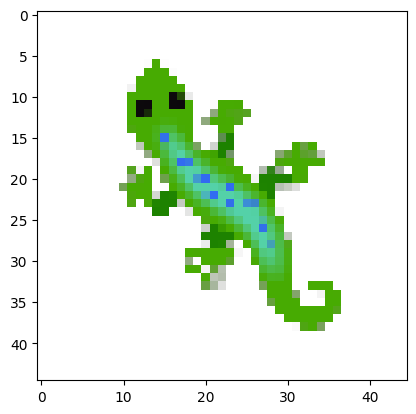

In [6]:
#@title Display Primitives { vertical-output: true}
seed = np.zeros([CHANNELS, HEIGHT, WIDTH], np.float32)
seed[3:, HEIGHT // 2, WIDTH // 2] = 1.0

pool = SamplePool(x=np.repeat(seed[None, ...], POOL_SIZE, axis=0))


plt.imshow(image_to_display)
plt.show()


In [7]:
#@title Get Batch Image Partitions { vertical-output: true}
batch = pool.sample(BATCH_SIZE)

In [8]:
#@title Load Filters for Loss Function { vertical-output: true}

sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [9]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/Gene created


In [11]:
#@title Initialise NCA { vertical-output: true}
base = image.tile(BATCH_SIZE, 1, 1, 1).to(DEVICE)
loss_log = []
nca = NCA_EBM(CHANNELS,HIDDEN_SIZE)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__

In [ ]:
def create_circular_mask(image_size, center_x, center_y, radius, device="cuda:0"):
    height, width = HEIGHT, WIDTH
    y_grid, x_grid = torch.meshgrid(
        torch.arange(height, device=device),
        torch.arange(width, device=device),
        indexing='ij'
    )
    distance_squared = (x_grid - center_x) ** 2 + (y_grid - center_y) ** 2
    return distance_squared <= (radius ** 2)

Batch


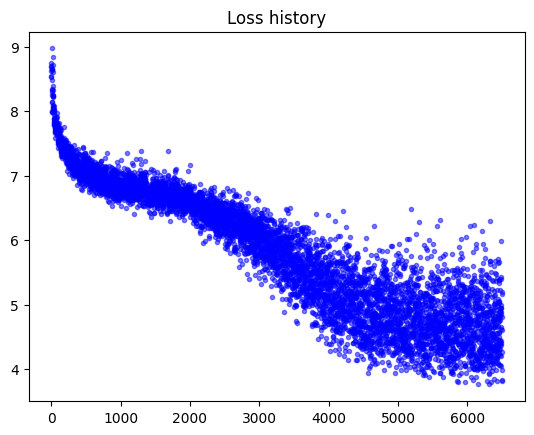

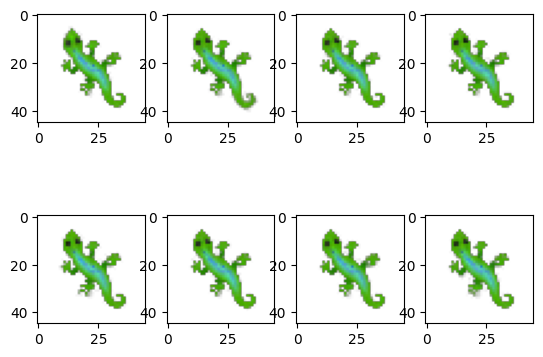

Trained_models/Gene/NCA_EBM.pth


In [ ]:
#@title Training { vertical-output: true}
DAMAGE_N = 3

lambda_mono = 0.05
lambda_drift = 0.05
K = 20


eta_log = []
j_norm_log = []
energy_loss = []
loss_mono_log = []
loss_drift_log = []

for i in range(TRAINING_ITERS + 1):
    with torch.no_grad():
        batch = pool.sample(BATCH_SIZE)
        x = torch.from_numpy(batch.x).to(DEVICE)

    T = random.randrange(32, 92)

    energies = []
    for t in range(T):
        E_t = nca.energy(x)
        energies.append(E_t)
        x = nca(x)

    live_mask = (base[:, 3:4] > 0.1).float()
    pixel_loss = (x[:, :4, :, :] - base).pow(2).mean(dim=[1, 2, 3])
    edge_loss = (perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)).pow(2).mean(dim=[1, 2, 3])

    per_sample_loss = pixel_loss + 0.1 * edge_loss
    loss_recon = per_sample_loss.mean()

    energies_t = torch.stack(energies[:-1])
    energies_t1 = torch.stack(energies[1:])
    loss_mono = torch.relu(energies_t1 - energies_t).sum()

    loss_drift = 0
    for t in range(K):
      x = nca(x)
      loss_drift = loss_drift + ((base - x[:, :4, :, :]) ).pow(2).sum()

    loss = loss_recon + lambda_mono * loss_mono + lambda_drift * loss_drift
    loss.backward()
    torch.nn.utils.clip_grad_norm_(nca.parameters(), max_norm=1.0)
    optim.step()
    optim.zero_grad()

    eta_log.append(nca.eta.detach().item())
    j_norm_log.append(nca.J.norm().item())
    loss_mono_log.append(loss_mono.item())
    loss_drift_log.append(loss_drift.item())
    energy_loss.append(loss.item())
    loss_log.append(loss.log().item())

    with torch.no_grad():
      x_np = x.detach().cpu().numpy()

      worst_idx = per_sample_loss.detach().cpu().numpy().argmax()
      x_np[worst_idx] = seed

      if DAMAGE_N > 0:
        # Get indices sorted by loss (lowest loss first)
        best_indices = per_sample_loss.argsort()[:DAMAGE_N]

        for idx in best_indices:
            # Randomize damage location and size
            cx = random.randint(int(WIDTH * 0.2), int(WIDTH * 0.8))
            cy = random.randint(int(HEIGHT * 0.2), int(HEIGHT * 0.8))
            r = random.randint(6, 14)

            mask_np = create_circular_mask(HEIGHT, cx, cy, radius=r).cpu().numpy()
            damage = 1.0 - mask_np[None, ...]

            # Apply damage specifically to this high-performing sample
            x_np[idx] *= damage

      batch.x[:] = x_np
      batch.commit()

    scheduler.step()



    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1, figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color="b")
        print("Batch")
        utils.show_batch(x[2:14])
        display(HTML(style))
        plt.show(block=False)
        plt.pause(0.01)


    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
        print("Trained_models/" + name + ".pth")


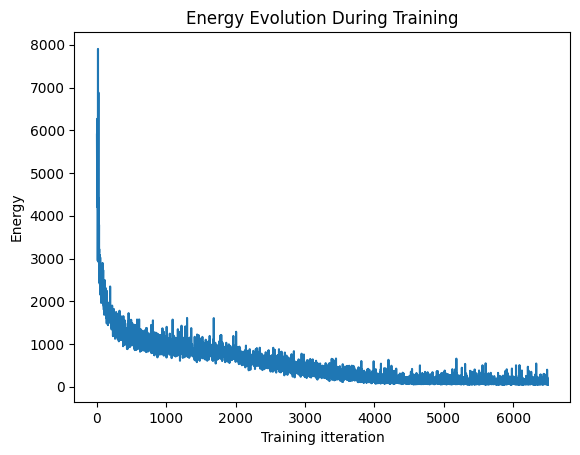

In [ ]:

plt.plot(energy_loss)
plt.xlabel("Training itteration")
plt.ylabel("Energy")
plt.title("Energy Evolution During Training")
plt.show()


In [ ]:
print(np.min(energy_loss))

42.95795822143555


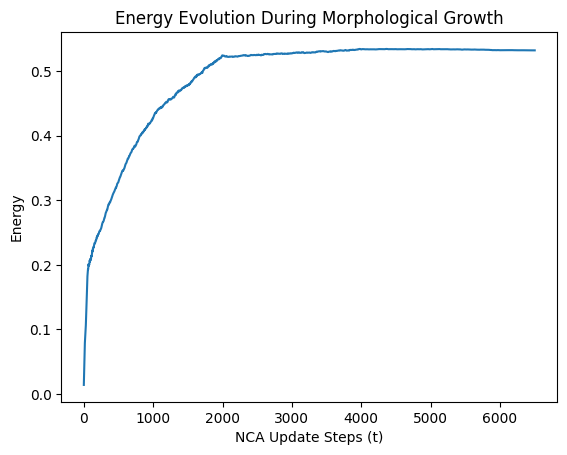

In [ ]:
plt.plot(j_norm_log)
plt.xlabel("NCA Update Steps (t)")
plt.ylabel("Energy")
plt.title("Energy Evolution During Morphological Growth")
plt.show()

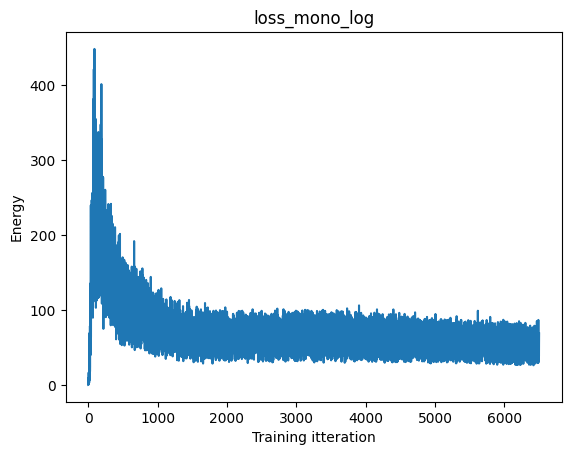

In [ ]:
plt.plot(loss_mono_log)
plt.title("loss_mono_log")
plt.xlabel("Training itteration")
plt.ylabel("Energy")
plt.show()

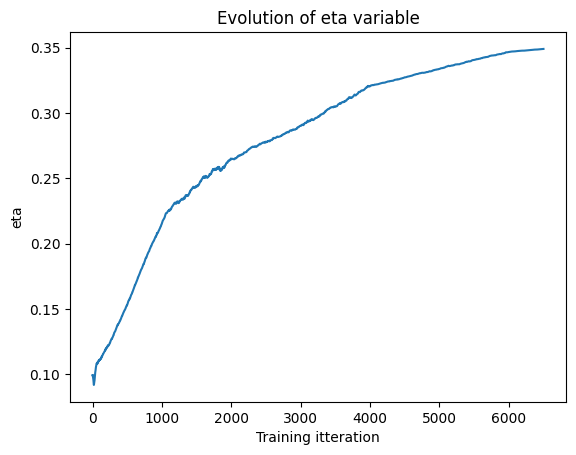

In [ ]:
plt.plot(eta_log)
plt.title("Evolution of eta variable")
plt.xlabel("Training itteration")
plt.ylabel("eta")
plt.show()

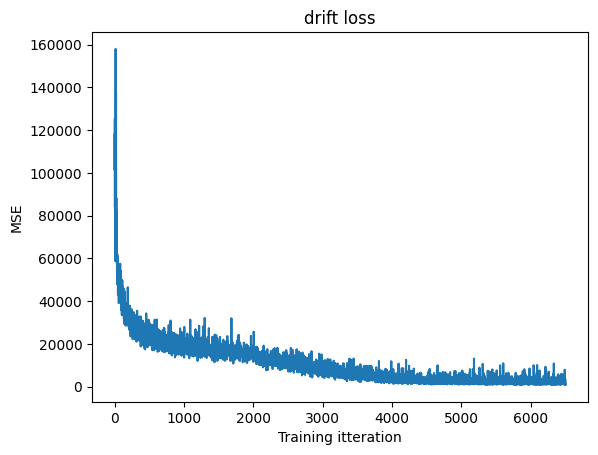

In [ ]:
plt.plot(loss_drift_log)
plt.title("drift loss")
plt.xlabel("Training itteration")
plt.ylabel("MSE")
plt.show()

In [12]:
del nca
del optim
torch.cuda.empty_cache()

In [13]:
nca = NCA_EBM(CHANNELS,hidden_n=HIDDEN_SIZE)
nca.load_state_dict(torch.load("Trained_models/Gene/NCA_EBM(2).pth"))
nca.to(DEVICE).eval()

NCA_EBM(
  (w1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
)

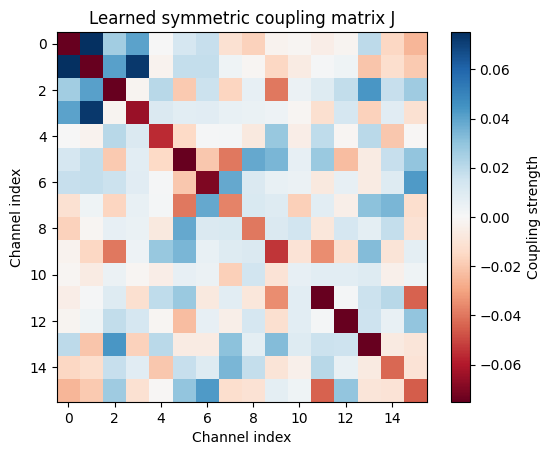

In [14]:
J_sym = ((nca.J + nca.J.T) / 2).detach().cpu().numpy()

plt.imshow(J_sym, cmap='RdBu', vmin=-J_sym.max(), vmax=J_sym.max())
plt.colorbar(label="Coupling strength")
plt.title("Learned symmetric coupling matrix J")
plt.xlabel("Channel index")
plt.ylabel("Channel index")
plt.show()

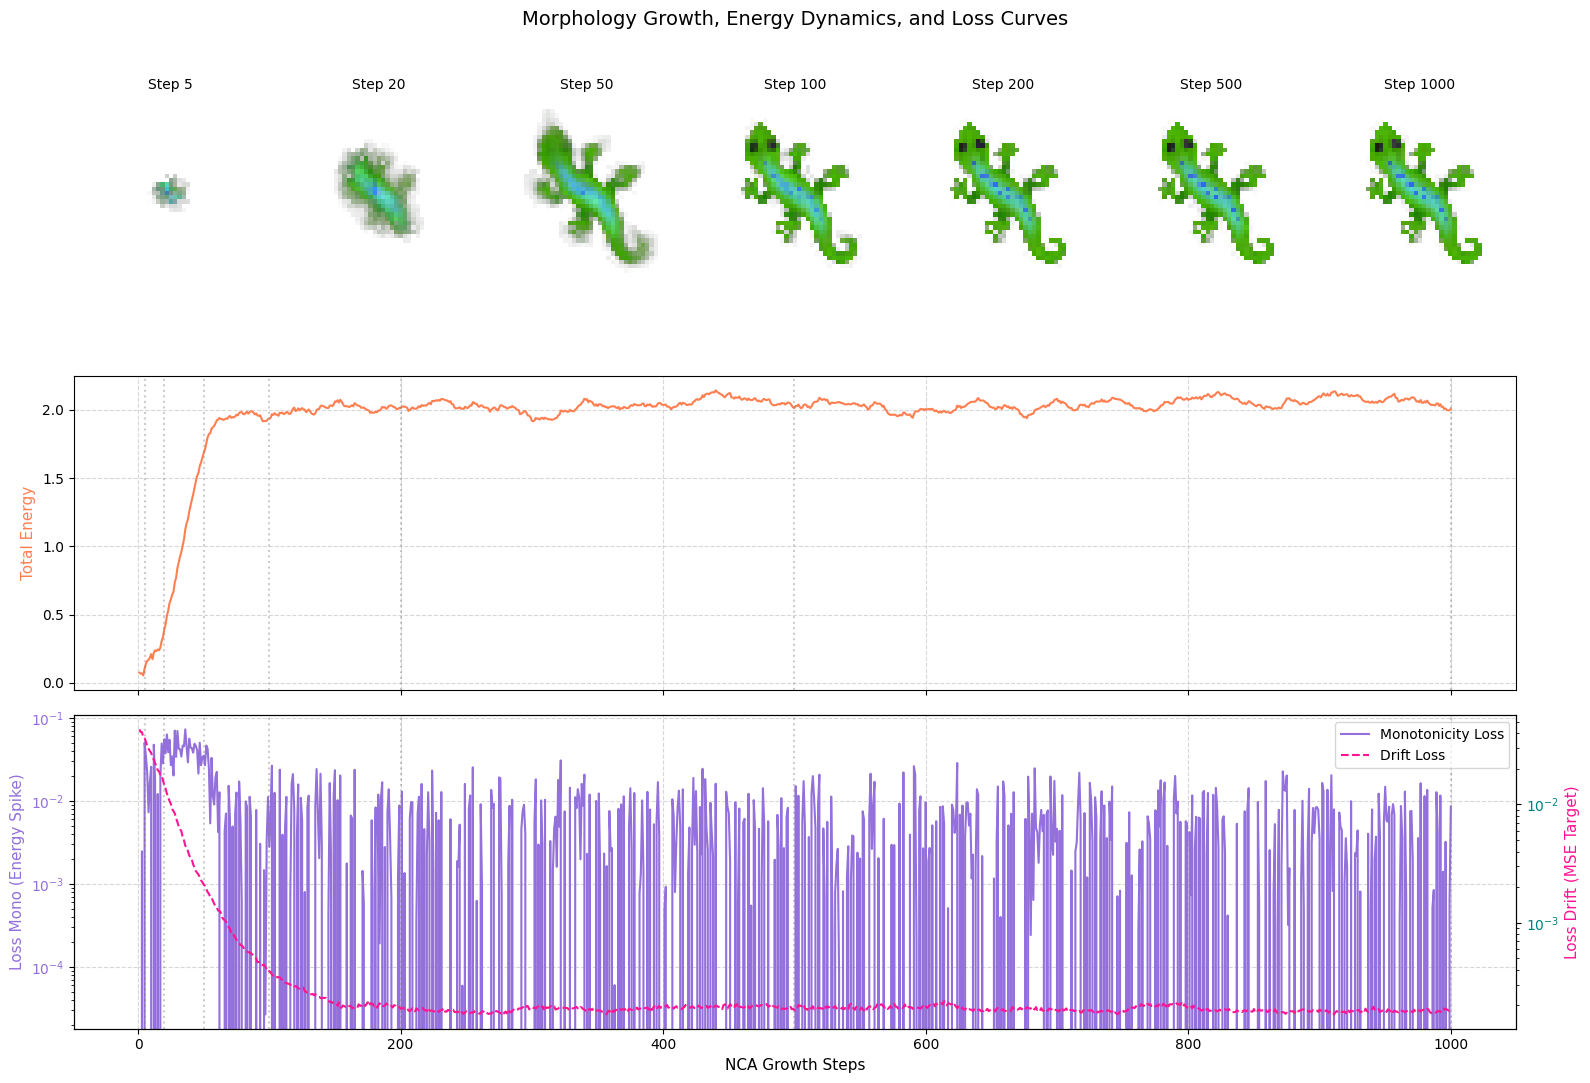

In [16]:
## Growing the morphology
def visualize_growth(nca, seed, base, steps_to_show=[5, 20, 50, 100, 200, 500, 1000], device='cuda:0'):
    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
    base_target = base.to(device)

    max_steps = max(steps_to_show)

    # Tracking metrics across steps
    total_energy_history = []
    loss_mono_history = []
    loss_drift_history = []
    captured_frames = []

    live_mask = (base_target[:, 3:4] > 0.1).float()

    with torch.no_grad():
        for step in range(1, max_steps + 1):
            x = nca(x)

            # 1. Total System Energy
            E = nca.energy(x)
            energy_val = E.sum().item() if torch.is_tensor(E) else float(E)
            total_energy_history.append(energy_val)

            # 2. Monotonicity Loss: ReLU(E_{t} - E_{t-1})
            if len(total_energy_history) > 1:
                dE = total_energy_history[-1] - total_energy_history[-2]
                mono_loss = max(0.0, dE)  # Equivalent to torch.relu for scalars
            else:
                mono_loss = 0.0
            loss_mono_history.append(mono_loss)

            # 3. Drift Loss: MSE against target base without mutating main state x
            # Simulates forward rollouts from current state to evaluate drift
            x_rollout = x.clone()
            drift_accum = 0.0
            for _ in range(20):
                x_rollout = nca(x_rollout)
                diff = (base_target[:, :4] - x_rollout[:, :4]) * live_mask
                drift_accum += diff.pow(2).mean().item()

            loss_drift_history.append(drift_accum / 20.0)

            # 4. Capture snapshots at milestone steps
            if step in steps_to_show:
                img = x[0, :4].permute(1, 2, 0).cpu().numpy()
                img = np.clip(img, 0, 1)
                captured_frames.append((step, img))

    # --- Plotting Grid Setup: 3 Rows ---
    fig = plt.figure(figsize=(16, 11))
    fig.suptitle("Morphology Growth, Energy Dynamics, and Loss Curves", fontsize=14, y=0.98)

    steps_range = np.arange(1, max_steps + 1)
    n_snapshots = len(steps_to_show)

    # --- 1. Top Row: Morphological Snapshots ---
    for i, (step, img) in enumerate(captured_frames):
        ax = fig.add_subplot(3, n_snapshots, i + 1)
        ax.imshow(img)
        ax.set_title(f"Step {step}", fontsize=10)
        ax.axis("off")

    # --- 2. Middle Row: Continuous System Energy ---
    ax_energy = fig.add_subplot(3, 1, 2)
    ax_energy.plot(steps_range, total_energy_history, color='coral', linewidth=1.5, label='Total Energy')
    ax_energy.set_ylabel("Total Energy", color='coral', fontsize=11)
    ax_energy.grid(True, linestyle='--', alpha=0.5)
    ax_energy.set_xticklabels([])  # Hide x-axis ticks for middle plot

    for s in steps_to_show:
        ax_energy.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # --- 3. Bottom Row: Separate Subplot for Loss Mono & Loss Drift ---
    ax_mono = fig.add_subplot(3, 1, 3)
    ax_drift = ax_mono.twinx()  # Dual Y-axis for scale separation

    # Loss Mono Plot (Left Y-Axis)
    line1 = ax_mono.plot(steps_range, loss_mono_history, color='mediumpurple', linewidth=1.5, label='Monotonicity Loss')
    ax_mono.set_ylabel("Loss Mono (Energy Spike)", color='mediumpurple', fontsize=11)
    ax_mono.tick_params(axis='y', labelcolor='mediumpurple')
    ax_mono.set_yscale('log')
    ax_mono.set_xlabel("NCA Growth Steps", fontsize=11)
    ax_mono.grid(True, linestyle='--', alpha=0.5)

    # Loss Drift Plot (Right Y-Axis)
    line2 = ax_drift.plot(steps_range, loss_drift_history, color='deeppink', linewidth=1.5, linestyle='--', label='Drift Loss')
    ax_drift.set_ylabel("Loss Drift (MSE Target)", color='deeppink', fontsize=11)
    ax_drift.tick_params(axis='y', labelcolor='deeppink')
    ax_drift.set_yscale('log')

    # Add milestone step markers to bottom plot
    for s in steps_to_show:
        ax_mono.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # Combined Legend for Bottom Panel
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax_mono.legend(lines, labels, loc='upper right')

    plt.tight_layout()
    plt.show()
visualize_growth(nca, seed, base)


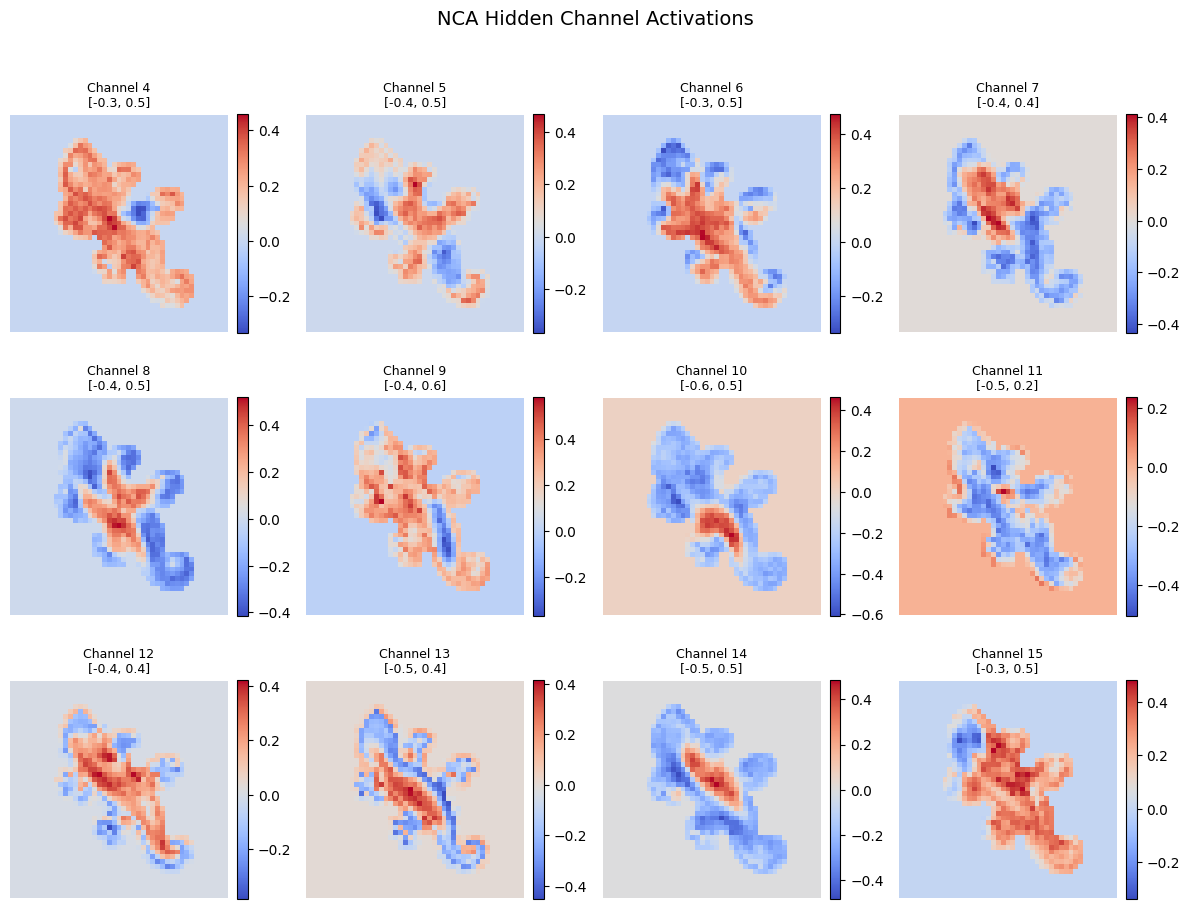

In [44]:
x = torch.from_numpy(seed[None, ...]).to(DEVICE) if isinstance(seed, np.ndarray) else seed.to(DEVICE)

with torch.no_grad():
    for t in range(400):
        x = nca(x)

# 2. Extract Hidden Channels (assuming channels 0..3 are RGBA)
# x shape: (1, total_channels, H, W)
hidden_channels = x[0, 4:].cpu().numpy()  # shape: (num_hidden_channels, H, W)
num_hidden = hidden_channels.shape[0]

# 3. Create a Grid of Heatmaps
cols = 4  # Display 4 heatmaps per row
rows = (num_hidden + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i in range(num_hidden):
    channel_data = hidden_channels[i]

    # Use a diverging colormap like 'coolwarm' or 'seismic' centered at 0
    # or 'viridis' to see relative magnitudes
    im = axes[i].imshow(channel_data, cmap='coolwarm')

    # Show min/max values in title to easily spot exploding values
    c_min, c_max = channel_data.min(), channel_data.max()
    axes[i].set_title(f"Channel {i+4}\n[{c_min:.1f}, {c_max:.1f}]", fontsize=9)
    axes[i].axis('off')

    # Optional: Add colorbar per subplot to inspect absolute values
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Turn off any unused subplots
for i in range(num_hidden, len(axes)):
    axes[i].axis('off')

plt.suptitle("NCA Hidden Channel Activations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
## Damage experiments

def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0
        x[:, :, :, cx - thickness:cx + thickness] = 0

    return x


def visualize_regeneration(nca, seed, base_target, damage='right_half',
                           total_steps=800, damage_step=400,
                           circle_radius=5, device='cuda:0'):

    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
    base_target = base_target.to(device)
    live_mask = (base_target[:, 3:4] > 0.1).float()

    # Metric tracking arrays
    total_energy_history = []
    loss_mono_history = []
    loss_drift_history = []

    frames = []
    frame_titles = []
    capture_steps = [0, damage_step - 1, damage_step, damage_step + 25, damage_step + 150, total_steps - 1]

    with torch.no_grad():
        for t in range(total_steps):
            # Apply damage at exact step
            if t == damage_step:
                x = apply_damage(x, damage_type=damage, circle_radius=circle_radius)

            # Step forward
            out = nca(x, step=t) if 'step' in nca.forward.__code__.co_varnames else nca(x)
            x = out[0] if isinstance(out, tuple) else out

            # 1. Total System Energy
            E = nca.energy(x)
            energy_val = E.sum().item() if torch.is_tensor(E) else float(E)
            total_energy_history.append(energy_val)

            # 2. Monotonicity Loss: ReLU(E_t - E_{t-1})
            if len(total_energy_history) > 1:
                dE = total_energy_history[-1] - total_energy_history[-2]
                mono_loss = max(0.0, dE)
            else:
                mono_loss = 0.0
            loss_mono_history.append(mono_loss)

            # 3. Drift Loss: 20-step forward rollout without mutating x
            x_rollout = x.clone()
            drift_accum = 0.0
            for r_step in range(20):
                r_out = nca(x_rollout, step=t + r_step) if 'step' in nca.forward.__code__.co_varnames else nca(x_rollout)
                x_rollout = r_out[0] if isinstance(r_out, tuple) else r_out
                diff = (base_target[:, :4] - x_rollout[:, :4]) * live_mask
                drift_accum += diff.pow(2).mean().item()

            loss_drift_history.append(drift_accum / 20.0)

            # 4. Capture Frame Snapshots
            if t in capture_steps:
                frame_img = x[0, :4].permute(1, 2, 0).cpu().clamp(0, 1).numpy()
                frames.append(frame_img)

                if t < damage_step:
                    frame_titles.append(f't={t} (Growth)')
                elif t == damage_step:
                    frame_titles.append(f't={t} (Damaged)')
                else:
                    frame_titles.append(f't={t} (+{t - damage_step})')

    # --- Plotting Grid Setup: 3 Rows ---
    fig = plt.figure(figsize=(16, 11))
    fig.suptitle(f"Morphology Regeneration Dynamics (Damage: '{damage}' at Step {damage_step})", fontsize=14, y=0.98)

    steps_range = np.arange(0, total_steps)
    n_frames = len(frames)

    # --- 1. Top Row: Regeneration Snapshots ---
    for i, (frame, title) in enumerate(zip(frames, frame_titles)):
        ax = fig.add_subplot(3, n_frames, i + 1)
        ax.imshow(frame)
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    # --- 2. Middle Row: System Energy Profile ---
    ax_energy = fig.add_subplot(3, 1, 2)
    ax_energy.plot(steps_range, total_energy_history, color='coral', linewidth=1.5, label='System Energy')
    ax_energy.axvline(x=damage_step, color='red', linestyle='--', linewidth=1.5, label='Damage Event')
    ax_energy.set_ylabel("Total Energy", color='coral', fontsize=11)
    ax_energy.grid(True, linestyle='--', alpha=0.5)
    ax_energy.set_xticklabels([])
    ax_energy.legend(loc='upper right')

    for s in capture_steps:
        ax_energy.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # --- 3. Bottom Row: Loss Mono & Loss Drift Dual-Axis ---
    ax_mono = fig.add_subplot(3, 1, 3)
    ax_drift = ax_mono.twinx()

    # Monotonicity Loss (Left Y-Axis)
    line1 = ax_mono.plot(steps_range, loss_mono_history, color='mediumpurple', linewidth=1.2, label='Monotonicity Loss')
    ax_mono.set_ylabel("Loss Mono", color='mediumpurple', fontsize=11)
    ax_mono.tick_params(axis='y', labelcolor='mediumpurple')
    ax_mono.set_yscale('log')
    ax_mono.set_xlabel("NCA Rollout Steps", fontsize=11)
    ax_mono.grid(True, linestyle='--', alpha=0.5)

    # Drift Loss (Right Y-Axis)
    line2 = ax_drift.plot(steps_range, loss_drift_history, color='deeppink', linewidth=1.2, linestyle='--', label='Drift Loss')
    ax_drift.set_ylabel("Loss Drift (MSE Target)", color='deeppink', fontsize=11)
    ax_drift.tick_params(axis='y', labelcolor='deeppink')
    ax_drift.set_yscale('log')

    # Damage Event & Capture Markers
    ax_mono.axvline(x=damage_step, color='red', linestyle='--', linewidth=1.5)
    for s in capture_steps:
        ax_mono.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # Combined Legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax_mono.legend(lines, labels, loc='upper right')

    plt.tight_layout()
    plt.show()

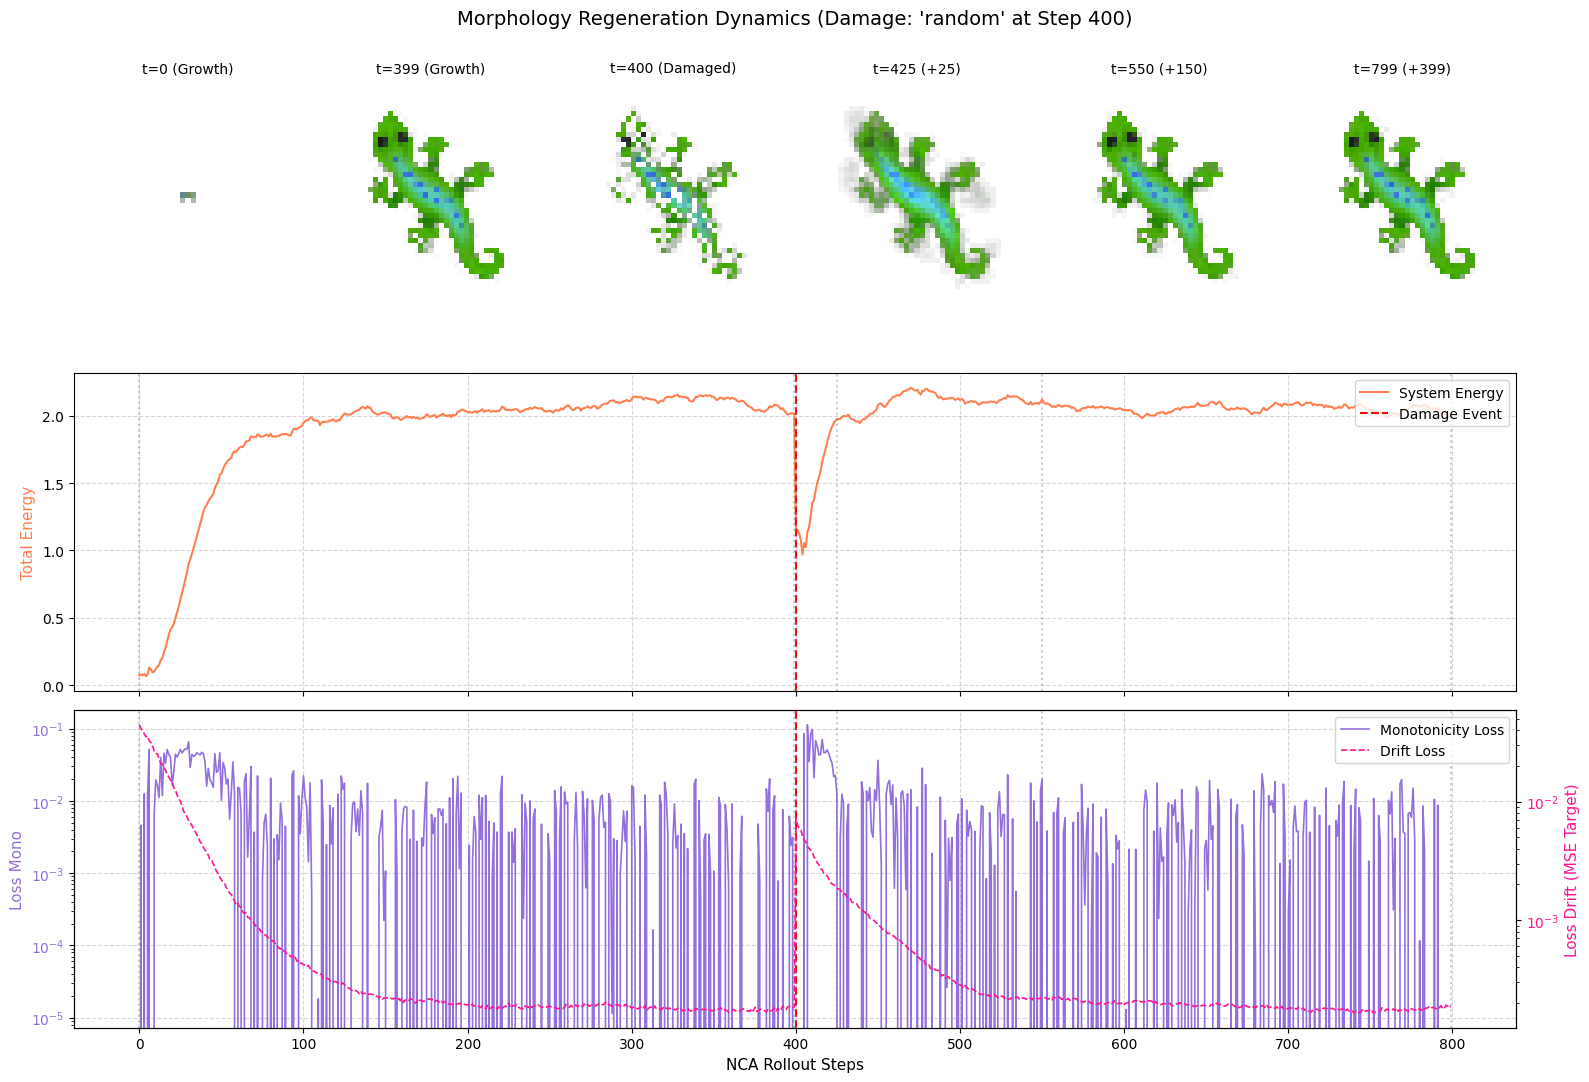

In [18]:
visualize_regeneration(nca, seed, base, "random")

In [43]:
def plot_hopfield_phase_portrait(nca, seed, base_target, steps=300, device='cuda:0'):
    """
    Plots state space trajectories using realistic biological perturbations:
    1. Growth from Seed
    2. Half Damage (Right Side)
    3. Center Hole Punch
    4. Hidden Memory Reset (Zeroing Channels 4:)
    """
    base_target = base_target.to(device)

    # 1. Process Initial Seed State
    if isinstance(seed, np.ndarray):
        init_seed = torch.from_numpy(seed[None, ...]).to(device) if seed.ndim == 3 else torch.from_numpy(seed).to(device)
    else:
        init_seed = seed.clone().to(device)
    if init_seed.ndim == 3:
        init_seed = init_seed.unsqueeze(0)

    # 2. Grow full baseline state (x_base)
    with torch.no_grad():
        x_base = init_seed.clone()
        for _ in range(steps):
            out = nca(x_base)
            x_base = out[0] if isinstance(out, tuple) else out

    # --- Construct 3 Meaningful Perturbed States ---
    # Perturbation A: Half Cutout
    init_half = x_base.clone()
    init_half[:, :, :, 32:] = 0.0

    # Perturbation B: Center Punch Hole
    init_hole = x_base.clone()
    h, w = init_hole.shape[2], init_hole.shape[3]
    cy, cx = h // 2, w // 2
    r = 8
    init_hole[:, :, cy-r:cy+r, cx-r:cx+r] = 0.0

    # Perturbation C: Hidden State Wipeout (Keeps RGBA, wipes memory)
    init_memory_wipe = x_base.clone()
    init_memory_wipe[:, 4:] = 0.0

    starting_states = [init_seed, init_half, init_hole, init_memory_wipe]
    labels = ['Seed Growth', 'Half Cut Damage', 'Center Hole Punch', 'Hidden Memory Reset']
    colors = ['royalblue', 'crimson', 'darkorange', 'purple']

    trajectories = []

    # 3. Collect State Trajectories
    with torch.no_grad():
        for start_state in starting_states:
            traj = []
            x = start_state.clone()
            for t in range(steps):
                out = nca(x, step=t) if 'step' in nca.forward.__code__.co_varnames else nca(x)
                x = out[0] if isinstance(out, tuple) else out

                feat = nca.perceive(x) if hasattr(nca, 'perceive') else x
                traj.append(feat[0].cpu().numpy().flatten())
            trajectories.append(np.array(traj))

    # 4. Extract Target Feature Vector
    with torch.no_grad():
        target_feat = nca.perceive(x_base) if hasattr(nca, 'perceive') else x_base
        target_flat = target_feat[0].cpu().numpy().flatten()[None, :]

    # 5. Fit PCA & Transform
    all_states = np.concatenate(trajectories + [target_flat], axis=0)
    pca = PCA(n_components=2)
    pca.fit(all_states)
    target_2d = pca.transform(target_flat)

    # 6. Render Refined Phase Portrait
    plt.figure(figsize=(9, 7))

    for traj, color, label in zip(trajectories, colors, labels):
        traj_2d = pca.transform(traj)
        plt.plot(traj_2d[:, 0], traj_2d[:, 1], color=color, alpha=0.85, linewidth=1.8, label=label)
        plt.scatter(traj_2d[0, 0], traj_2d[0, 1], color=color, marker='o', s=60)
        plt.scatter(traj_2d[-1, 0], traj_2d[-1, 1], color=color, marker='X', s=90)

    # Draw Hopfield Minimum Target Point
    plt.scatter(target_2d[0, 0], target_2d[0, 1], color='gold', edgecolor='black', marker='*', s=350, zorder=5, label='Hopfield Minimum (Target)')

    plt.xlabel('Principal Component 1', fontsize=11)
    plt.ylabel('Principal Component 2', fontsize=11)
    plt.title('Hopfield Phase Portrait: Converging Trajectories under Structural Damage', fontsize=13)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

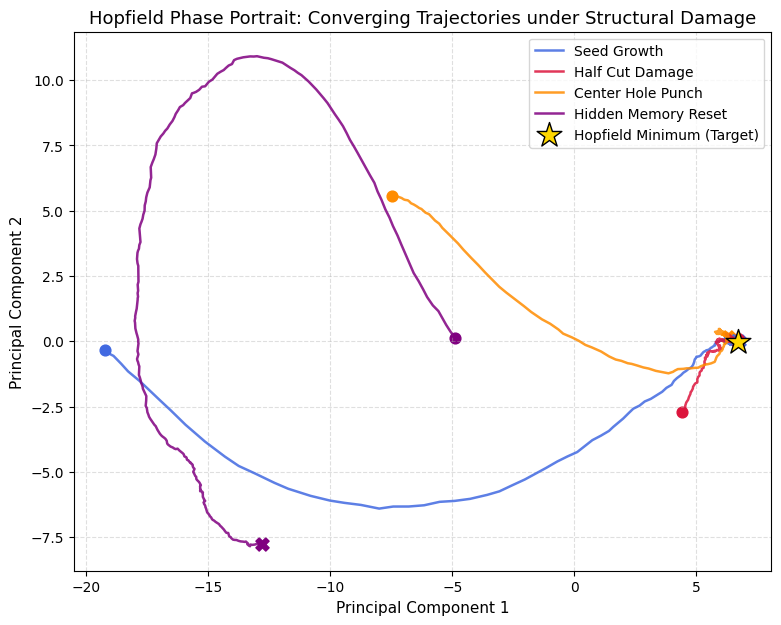

In [44]:
plot_hopfield_phase_portrait(nca,seed, base)

In [40]:
del nca
torch.cuda.empty_cache()